# 03 · From detection to question

A detection is a box, a label, and a score. A traveller wants a question. This
notebook is about the gap between those two things, and it contains the most
useful result in the project, which is a **negative** one.

All generated text below is read from committed results. Nothing here calls an
API or needs a key.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 90)

SAMPLE = REPO_ROOT / "data" / "sample"
RESULTS = REPO_ROOT / "results"
print("Repository root:", REPO_ROOT.name)


Repository root: portfolio-clean


In [2]:
import json
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image

# Photographs re-encode as PNG in notebook output, which is what drives .ipynb
# file size. 72 dpi keeps the committed notebooks light enough to render quickly
# on GitHub while staying perfectly legible.
plt.rcParams["figure.dpi"] = 72


def load_sample_coco(amenity):
    """Ground-truth boxes for the committed sample, keyed by file name."""
    coco = json.loads((SAMPLE / amenity / "_annotations.coco.json").read_text())
    by_id = {i["id"]: i["file_name"] for i in coco["images"]}
    boxes = {}
    for ann in coco["annotations"]:
        x, y, w, h = ann["bbox"]
        boxes.setdefault(by_id[ann["image_id"]], []).append([x, y, x + w, y + h])
    return coco, boxes


def show_detections(amenity, file_names, detections, gt_boxes, conf, ncols=3):
    """Green = ground truth, orange = detection above `conf`."""
    nrows = (len(file_names) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 4.2 * nrows))
    axes = axes.ravel() if hasattr(axes, "ravel") else [axes]

    for ax, name in zip(axes, file_names):
        ax.imshow(Image.open(SAMPLE / amenity / name).convert("RGB"))
        for x1, y1, x2, y2 in gt_boxes.get(name, []):
            ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1,
                                   fill=False, edgecolor="#2E9B57", linewidth=2.5))
        hits = detections[(detections["image"] == name) & (detections["score"] > conf)]
        for _, d in hits.iterrows():
            ax.add_patch(Rectangle((d.x1, d.y1), d.x2 - d.x1, d.y2 - d.y1,
                                   fill=False, edgecolor="#E07B39", linewidth=2.0,
                                   linestyle="--"))
            ax.text(d.x1, max(d.y1 - 6, 10), f"{d.score:.2f}", color="#E07B39",
                    fontsize=9, fontweight="bold")
        n_gt = len(gt_boxes.get(name, []))
        ax.set_title(f"{n_gt} ground truth · {len(hits)} detected", fontsize=9)
        ax.axis("off")

    for ax in axes[len(file_names):]:
        ax.axis("off")
    fig.suptitle("green = ground truth    orange dashed = OWL-ViT detection",
                 fontsize=10, y=1.005)
    plt.tight_layout()
    plt.show()


## The first approach: describe the detection in words

The obvious design. Turn the detection row into a short textual summary, wrap it
in a system instruction, send it to a language model.

One detail worth noting: the raw confidence score is **bucketed** rather than
passed through verbatim. Handing a model `0.7214` invited it to invent matching
precision in the question text ("is this likely-to-be-a-bathtub..."), so it
receives a band instead.

In [3]:
from src.question_generation.prompts import build_prompt, detection_summary

detections = pd.read_csv(RESULTS / "detection_outputs" / "bathtub" / "dets_bathtub_baseline.csv")
row = detections.sort_values("score", ascending=False).iloc[0]

print(detection_summary(row))
print()
print("-" * 78)
print(build_prompt(detection_summary(row)))

Image file: image_132_jpg.rf.9fd63dad427c4c41a86d4d845b5f331a.jpg. Detected amenity: bathtub. Detection confidence: high confidence (0.79). Source prompt type: baseline.

------------------------------------------------------------------------------
You help travellers evaluate accommodation listings. Given a detected amenity in a hotel photo, write ONE short question a guest might want answered before booking. Keep it factual, neutral, answerable from the photo or the listing, and grounded in the detected object. Return only the question.
Detection summary: Image file: image_132_jpg.rf.9fd63dad427c4c41a86d4d845b5f331a.jpg. Detected amenity: bathtub. Detection confidence: high confidence (0.79). Source prompt type: baseline.
Question:


## Finding 3: text-only conditioning collapses into templates

Here is the problem, and it is visible without any metric. These are real
generated questions from four backends over the same 1,003 detections.

In [4]:
generated = pd.read_csv(
    RESULTS / "question_generation_outputs" / "bathtub"
    / "merged_detections_bathtub_with_questions_all_models.csv"
)
question_cols = [c for c in generated.columns if c.startswith("generated_question")]

print(f"{len(generated)} detections, {len(question_cols)} backends\n")
generated[["image"] + question_cols].head(5)

1003 detections, 4 backends



,image,generated_question_flan_base,generated_question_flan_large,generated_question_llama70b,generated_question_llama8b
0,image_28_jpg.rf.b8535e3aa3218282cc77a22a4746d940.jpg,What type of amenity does the image show?,What type of amenity is the bathtub?,Does the room have a bathtub?,Is there a bathtub in the room?
1,image_28_jpg.rf.b8535e3aa3218282cc77a22a4746d940.jpg,What is the name of the hotel amenity?,What type of amenity is the bathtub?,Does the room have a bathtub?,Does the bathtub have a shower attachment?
2,image_107_jpg.rf.af5e3a5945f12270da1104b704bdc995.jpg,What type of amenity does the image show?,What type of amenity is the bathtub?,Does the room have a bathtub?,Does the hotel room have a separate shower?
3,image_182_jpg.rf.d060435883ce78592cae06e17b14f735.jpg,Which hotel amenity is most likely to be a bathtub?,What type of amenity is the bathtub?,Does this room have a bathtub?,Is there a bathtub in the room?
4,image_189_jpg.rf.4cea852ad7c21055001c0bbcd5a04701.jpg,What type of amenity is the bathtub in a hotel?,What is the name of the hotel's bathtub?,Does this room have a bathtub?,Is the bathtub a freestanding or built-in fixture?


Different images. Different confidence scores. Nearly identical questions.

Counting how often each backend repeats itself makes the scale of it obvious:

In [5]:
for col in question_cols:
    values = generated[col].dropna().astype(str)
    top, count = values.value_counts().index[0], values.value_counts().iloc[0]
    backend = col.replace("generated_question_", "")
    print(f"{backend:14s} {count:>4} / {len(values)} rows ({count/len(values):>5.1%})   \"{top[:58]}\"")

flan_base       592 / 1003 rows (59.0%)   "What is the name of the hotel amenity?"
flan_large      307 / 1003 rows (30.6%)   "What is the name of the bathroom amenity?"
llama70b        429 / 1003 rows (42.8%)   "Does the room have a bathtub?"
llama8b         130 / 1003 rows (13.0%)   "Is the bathtub separate from the shower?"


**Why this happens.** Look again at the prompt above. It carries
`label + confidence band + prompt type`. Across 1,003 bathtub detections that
input is nearly identical every time. The label is always "bathtub", the
confidence band takes three values, the prompt type one. The model is being asked
the same question a thousand times, so it gives the same answer.

The detection is *information-poor by construction*. Everything that makes one
bathtub different from another (its size, its condition, whether there is a
shower over it) was thrown away the moment the detection became a text summary.

### The metric that hides it

This is the part worth dwelling on. Standard question-quality metrics score this
output as a complete success.

In [6]:
from src.evaluation import question_metrics as qm

rows = []
for col in question_cols:
    stats = qm.summarize(generated[col].dropna().astype(str).tolist())
    stats["backend"] = col.replace("generated_question_", "")
    rows.append(stats)

quality = pd.DataFrame(rows).set_index("backend")
quality[["n", "fallback_rate", "well_formed_rate", "distinct_2", "duplicate_rate"]]

,n,fallback_rate,well_formed_rate,distinct_2,duplicate_rate
backend,,,,,
flan_base,1003,0.0,1.0,0.0068,0.9811
flan_large,1003,0.0,1.0,0.0050,0.9890
llama70b,1003,0.0,1.0,0.0114,0.9761
llama8b,1003,0.0,1.0,0.0355,0.8026


Every backend scores **0% fallback** and **100% well-formedness**. By those two
measures the system works perfectly.

Well-formedness asks "is this shaped like a question?" It cannot see that it is
the *same* question 592 times. Only `distinct_2` and `duplicate_rate` catch it.

The generalisable lesson: **any evaluation of generated text needs a diversity
term, or it will report success on a system that has collapsed.** A dashboard
tracking only fluency and fallback rate would have shown green throughout.

## The fix: condition on the image, not a description of it

If the problem is that the text summary discards what makes each detection
distinct, the fix is to stop discarding it and pass the model the actual pixels.

The detected region is cropped with 35% padding on each side. The padding
matters: a tight crop of a kettle is just a kettle, while the surrounding context
is what lets a model ask about counter space or reachability.

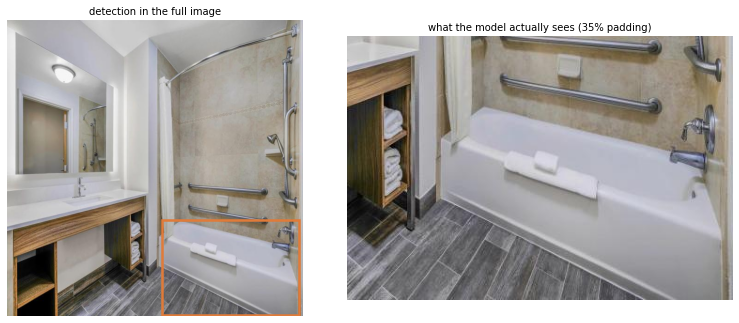

image_101_jpg.rf.e93a0eb31dea15d1fda213a8e42ff961.jpg   score 0.765


In [7]:
from src.question_generation.prompts import pad_box

coco, gt = load_sample_coco("bathtub")
sample_names = {i["file_name"] for i in coco["images"]}

vision = pd.read_csv(
    RESULTS / "question_generation_outputs" / "bathtub"
    / "dets_bathtub_baseline_gemini3_perspectives.csv"
)
subject = vision[vision["image"].isin(sample_names)].sort_values("score", ascending=False).iloc[0]

image = Image.open(SAMPLE / "bathtub" / subject["image"]).convert("RGB")
box = [subject.x1, subject.y1, subject.x2, subject.y2]
crop = image.crop(pad_box(box, image.size, 0.35))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
axes[0].imshow(image)
axes[0].add_patch(Rectangle((box[0], box[1]), box[2] - box[0], box[3] - box[1],
                            fill=False, edgecolor="#E07B39", linewidth=2.5))
axes[0].set_title("detection in the full image", fontsize=10)
axes[1].imshow(crop)
axes[1].set_title("what the model actually sees (35% padding)", fontsize=10)
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

print(f"{subject['image']}   score {subject['score']:.3f}")

### Same detection, both approaches

This is the comparison the whole project builds toward.

In [8]:
text_row = generated[generated["image"] == subject["image"]].iloc[0]

print("TEXT-ONLY CONDITIONING")
print("=" * 78)
for col in question_cols:
    print(f"  {col.replace('generated_question_', ''):14s} {text_row[col]}")

print()
print("VISION CONDITIONING (Gemini 3.0 Pro Preview, same detection)")
print("=" * 78)
for perspective in ["single", "couple", "group"]:
    print(f"  travelling {perspective}:")
    for i in (1, 2, 3):
        print(f"      {subject[f'gemini_3_{perspective}_q{i}']}")

TEXT-ONLY CONDITIONING
  flan_base      What type of amenity does a bathtub have?
  flan_large     What type of amenity is the bathtub?
  llama70b       Does this room have a bathtub?
  llama8b        Does the room have a separate shower stall?

VISION CONDITIONING (Gemini 3.0 Pro Preview, same detection)
  travelling single:
      Is the tub deep enough for a proper soak after a long day, or is it fairly shallow?
      I see several grab bars on the wall; is this room specifically designed for accessibility?
      Is the showerhead fixed, or is there a handheld wand for easier rinsing?
  travelling couple:
      Is this a standard-sized tub, or is it spacious enough for two people to relax in together?
      The bathroom looks a bit compact; is there enough room to move around if one person is at the sink while the other is showering?
      Does the tub feel high-quality and sturdy, or is it a basic plastic insert?
  travelling group:
      Are the sides of the bathtub low enough to e

The vision-conditioned questions are about *this* bathroom. They reference what
is in the frame. And because the model can see the scene, conditioning on who is
travelling produces genuinely different questions rather than the same sentence
with a word swapped.

### Measuring it

`scripts/build_finding3_table.py` regenerates this from the committed CSVs.

The comparison is **size-matched**: `distinct-n` falls as a corpus grows, so
comparing 2,484 vision questions against 1,003 text-only ones would flatter the
vision numbers. The vision row is the mean over 20 random subsamples of exactly
1,003 questions.

In [9]:
import random, statistics

vision_cols = [c for c in vision.columns if c.startswith("gemini_3_")]
vision_qs = [str(v).strip() for c in vision_cols for v in vision[c].dropna() if str(v).strip()]

d2, dup = [], []
for seed in range(20):
    random.seed(seed)
    stats = qm.summarize(random.sample(vision_qs, len(generated)))
    d2.append(stats["distinct_2"])
    dup.append(stats["duplicate_rate"])

comparison = quality[["distinct_2", "duplicate_rate"]].copy()
comparison["conditioning"] = "text"
comparison.loc["gemini_vision"] = [statistics.mean(d2), statistics.mean(dup), "vision"]
comparison

,distinct_2,duplicate_rate,conditioning
backend,,,
flan_base,0.006800,0.98110,text
flan_large,0.005000,0.98900,text
llama70b,0.011400,0.97610,text
llama8b,0.035500,0.80260,text
gemini_vision,0.272985,0.04667,vision


In [10]:
text_best = quality["distinct_2"].max()
print(f"Best text-only distinct-2 : {text_best:.3f}")
print(f"Vision distinct-2         : {statistics.mean(d2):.3f}  "
      f"({statistics.mean(d2)/text_best:.0f}x better, range {min(d2):.3f}–{max(d2):.3f})")
print(f"Duplicate rate            : {quality['duplicate_rate'].min():.1%} → "
      f"{statistics.mean(dup):.1%}")

Best text-only distinct-2 : 0.035
Vision distinct-2         : 0.273  (8x better, range 0.269–0.281)
Duplicate rate            : 80.3% → 4.7%


## Two caveats I want to state myself

**This is not a clean ablation.** Gemini 3.0 Pro Preview is a stronger model than
Flan-T5 independently of what it is shown. The comparison establishes that
*vision-conditioning with a capable model* beats *text-conditioning with these
models*. It does not isolate the contribution of the crop. The clean experiment
is the same model run with and without the image, and it was not done.

**Diversity is not quality.** These questions are more varied. They were never
put in front of the study participants, so there is no evidence they are more
*helpful*. Notebook 04 shows why that distinction matters more than it sounds.